# Polynomial Regression

## What Is Polynomial Regression?

Polynomial regression is, at its core, still linear regression. The only difference is that we **transform the input features** before fitting the model.

Instead of fitting a straight line:

$$y = \theta_0 + \theta_1 x$$

We allow the model to fit curves by including higher powers of $x$:

$$y = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3 + \cdots + \theta_d x^d$$

The model is **nonlinear in** $x$, but it is still **linear in the parameters** $\theta$. This is the key insight — because the relationship is linear in $\theta$, we can still solve it using exactly the same linear regression machinery (the Normal Equation, gradient descent, etc.).

## Why Do We Need It?

Many real-world relationships are not straight lines. Examples include:

- Growth curves (population, bacteria)
- Projectile motion (parabolic path)
- Diminishing returns in economics
- Temperature vs. reaction rate in chemistry

When the true relationship is curved, a straight line **underfits** the data — it is too rigid to capture the structure. Polynomial regression introduces curvature while keeping the simplicity of a linear model.

## Mathematical Formulation

Given a feature vector:

$$\mathbf{X} = \begin{bmatrix} x_1 \\ x_2 \\ x_3 \\ \vdots \end{bmatrix}$$

For degree $d = 2$, we transform it into an expanded feature matrix $\Phi(\mathbf{X})$:

$$\Phi(\mathbf{X}) = \begin{bmatrix} 1 & x_1 & x_1^2 \\ 1 & x_2 & x_2^2 \\ 1 & x_3 & x_3^2 \\ \vdots & \vdots & \vdots \end{bmatrix}$$

Each row now has three columns: the bias term, the original feature, and its square. We then solve the standard linear regression problem on this expanded matrix:

$$\mathbf{y} = \Phi(\mathbf{X})\theta$$

Using the Normal Equation:

$$\theta = (\Phi^T\Phi)^{-1}\Phi^T\mathbf{y}$$

This means polynomial regression is mathematically equivalent to running linear regression on an expanded feature space. No new algorithm is needed.

## The Multiple Features Case

When we have more than one input feature, the expansion becomes richer. For two features $x_1$ and $x_2$ with degree $d = 2$, the expanded feature set becomes:

$$1, \quad x_1, \quad x_2, \quad x_1^2, \quad x_2^2, \quad x_1 x_2$$

Notice the **interaction term** $x_1 x_2$. This term captures the combined effect of two features together — something a standard linear model cannot express. Polynomial regression automatically generates these interaction terms as part of the expansion.

This is powerful, but it also means the number of features grows rapidly with degree and dimensionality. This is discussed further below.

## When To Use Polynomial Regression

**Use it when:**

- A scatter plot of your data shows clear curvature
- Linear regression underfits (low training score)
- The underlying relationship is smooth but nonlinear
- You want an interpretable model that is still analytically solvable

**Avoid it when:**

- The data is extremely noisy — the model will chase noise
- The degree is too high — overfitting becomes severe
- The number of features is large — the feature explosion problem (see below)

## Bias–Variance Tradeoff and Overfitting

Polynomial regression makes the bias–variance tradeoff very visible. As the degree $d$ increases:

| Degree | Bias | Variance | Behavior |
|---|---|---|---|
| Too low | High | Low | Underfitting — model too rigid |
| Just right | Low | Low | Good generalization |
| Too high | Low | High | Overfitting — model too flexible |

At a very high degree, the model can pass through every training point almost perfectly, giving a training $R^2 \approx 1$. But on unseen test data, performance collapses — the model has memorized noise instead of learning the true pattern.

This is why **degree is a hyperparameter** that must be selected carefully, typically using cross-validation.

## Feature Explosion

Every time you increase the degree or add more input features, the number of expanded features grows rapidly. For $n$ input features and polynomial degree $d$, the number of terms in the expanded feature space grows as:

$$\binom{n + d}{d}$$

For example, with $n = 3$ features and degree $d = 10$, this produces hundreds of new features. This is called **feature explosion**.

Feature explosion creates two problems:

- The model becomes much more prone to overfitting
- Computation becomes expensive

This is why **Polynomial Regression combined with Ridge regularization** is a very common pattern in practice. The polynomial expansion gives the model the flexibility to fit curves, while Ridge penalizes large weights and prevents the model from overfitting the many new features.

## A Note on Feature Scaling

For pure polynomial regression without regularization, scaling is not strictly required — the Normal Equation will still find the correct solution.

However, if you combine polynomial features with any regularization (Ridge, Lasso, or Elastic Net), **scaling becomes essential**. Regularization penalizes large weights, but if features are on different scales, the penalty is applied unevenly — features with large numerical ranges are penalized more than they should be. Standardizing features first ensures the regularization is applied fairly across all of them.

## Elastic Net Regularization with Scaling

This code demo showcases the use of Elastic Net Regularization with StandardScaler, to avoid value explosion in polynomial regression. The higher the degree, the higher the variables tends to explode in values.

$$if \;x = 5,$$
$$then \;x^3 = 125$$

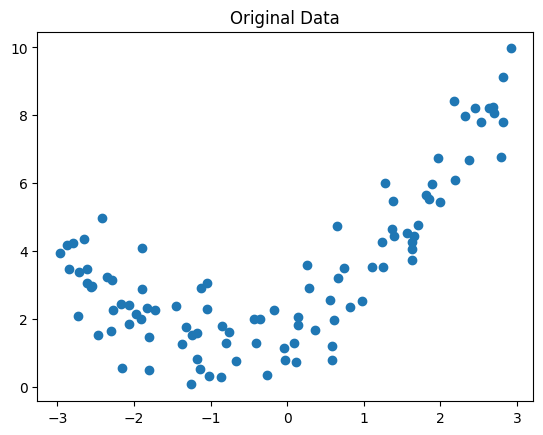

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge

np.random.seed(42)

X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)

plt.scatter(X, y)
plt.title("Original Data")
plt.show()

In [ ]:

plt.scatter(X, y)
plt.title("Original Data")
plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly_model = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
)
poly_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [13]:
y_pred = poly_model.predict(X_test)
print("R2:", r2_score(y_test, y_pred))

R2: 0.8544154872112257


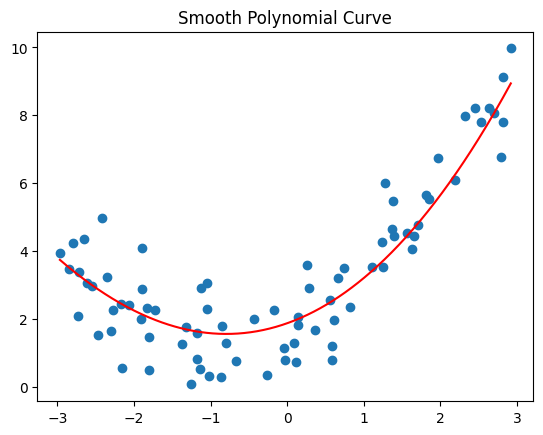

In [14]:
X_range = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)

y_range_pred = poly_model.predict(X_range)

plt.scatter(X_train, y_train)
plt.plot(X_range, y_range_pred, color="red")
plt.title("Smooth Polynomial Curve")
plt.show()